# 02 — Crime-risk prediction harness (leave-one-city-out)

**Single modeling target: `log(weighted total rate)`** — the carrier-eval weighted score
(equal-representation average of per-crime *relative risks*, rescaled to per-1,000
**residents**), logged. Built in `build_model_table` from the foundation weighted-score math
(ADR 0005); population denominator, so it is comparable to the national `*_pt_u` benchmarks.

We evaluate under **rotating leave-one-city-out (LOCO)**: fit on 4 cities, score the 5th,
rotate. Two target forms share one design matrix (scaler fit on **train cities only** →
leakage-safe):

- **`lograte`** (pooled / *reported*): the absolute `log(wtotal_rate)` on one intercept —
  answers *"how high is this BG's rate"* and exposes cross-city level transfer (OOS R²/MAE).
- **`lograte_within_city`** (*product target*): the same log-rate **z-scored per city**, so
  the fit learns *within-city relative risk* with each city's baseline level + spread removed
  — this is what the product ranks.

Headline metrics: **adjusted R²** (in-sample fit quality) and **MAE** (out-of-sample error),
plus rank/concentration diagnostics (Spearman, skill, capture@20).

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_here = Path.cwd().resolve()
_root = next(p for p in [_here, *_here.parents] if (p / "src").is_dir())
sys.path.insert(0, str(_root / "src"))

from regression_modelling.models.cv import (
    full_coverage_cities, load_pooled_table, loco_folds,
    run_loco, loco_metrics, plot_lorenz, make_target,
)
from regression_modelling.constants import PREDICTOR_COLS

CATEGORY = "wtotal"          # the weighted-total crime aggregate

In [2]:
# 5 full-coverage cities (crime source geolocates violent crime incl. rape) — derived from
# CityConfig.property_only, never hardcoded. Population denominator: load_pooled_table drops
# zero/NaN-pop BGs and small-denominator artifacts (daytime_pop floor) that manufacture skew.
cities = full_coverage_cities()
pooled = load_pooled_table()
print("cities:", cities)
print("pooled BGs:", len(pooled))
print("predictors:", len(PREDICTOR_COLS))

  houston            1629 BGs
  chicago            2164 BGs
  atlanta             426 BGs
  kansas_city         473 BGs
  detroit             622 BGs
  pooled             5314 BGs across 5 cities
  dropped 22 zero/NaN-pop BGs -> 5292 remain (filtered geoid set for fit + Moran's I + bias join)
  dropped 8 BGs below daytime_pop 100 (small-denominator rate artifacts) -> 5284 remain
cities: ['houston', 'chicago', 'atlanta', 'kansas_city', 'detroit']
pooled BGs: 5284
predictors: 23


## 1 — Headline LOCO results on `log(weighted total rate)`

`run_loco(..., category="wtotal")` for each target form. `adj_r2_in` is the fold's in-sample
adjusted R²; `mae` / `r2_oos` are out-of-sample (absolute `lograte` mode only — the
within-city z-scored target is unitless so only rank metrics apply).

In [3]:
run_pool = run_loco(pooled, mode="lograte", category=CATEGORY)              # reported (absolute)
run_wc   = run_loco(pooled, mode="lograte_within_city", category=CATEGORY)  # product (within-city)

LOCO — target mode = 'lograte' (wtotal)


  holdout=atlanta        n_train= 4645 scored=  369 adjR2_in= 0.479
  holdout=chicago        n_train= 2950 scored= 2064 adjR2_in= 0.448


  holdout=detroit        n_train= 4414 scored=  600 adjR2_in= 0.475


  holdout=houston        n_train= 3478 scored= 1536 adjR2_in= 0.531


  holdout=kansas_city    n_train= 4569 scored=  445 adjR2_in= 0.467
  -> 5014 BGs scored out-of-sample across 5 folds
LOCO — target mode = 'lograte_within_city' (wtotal)


  holdout=atlanta        n_train= 4645 scored=  369 adjR2_in= 0.412


  holdout=chicago        n_train= 2950 scored= 2064 adjR2_in= 0.353


  holdout=detroit        n_train= 4414 scored=  600 adjR2_in= 0.477


  holdout=houston        n_train= 3478 scored= 1536 adjR2_in= 0.461


  holdout=kansas_city    n_train= 4569 scored=  445 adjR2_in= 0.402
  -> 5014 BGs scored out-of-sample across 5 folds


In [4]:
# reported (absolute) target — adjusted R2 + out-of-sample MAE/R2
loco_metrics(run_pool)[["n", "adj_r2_in", "mae", "r2_oos", "skill", "spearman"]]

,n,adj_r2_in,mae,r2_oos,skill,spearman
holdout,,,,,,
atlanta,369,0.479,1.90,-2.062,0.541,0.708
chicago,2064,0.448,0.58,0.482,0.698,0.731
detroit,600,0.475,0.61,0.046,0.504,0.430
houston,1536,0.531,0.71,0.335,0.628,0.604
kansas_city,445,0.467,0.69,0.515,0.737,0.780
POOLED,5014,NaN,0.73,0.227,0.580,0.627


In [5]:
# product (within-city standardized) target — the ranking the product consumes
loco_metrics(run_wc)[["n", "adj_r2_in", "skill", "spearman", "capture@20"]]

,n,adj_r2_in,skill,spearman,capture@20
holdout,,,,,
atlanta,369,0.412,0.571,0.714,0.320
chicago,2064,0.353,0.706,0.684,0.397
detroit,600,0.477,0.504,0.439,0.270
houston,1536,0.461,0.621,0.569,0.388
kansas_city,445,0.402,0.733,0.765,0.421
POOLED,5014,NaN,0.551,0.574,0.331


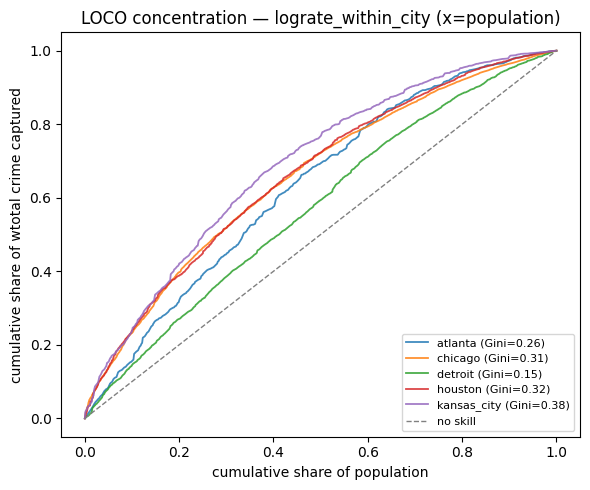

<Axes: title={'center': 'LOCO concentration — lograte_within_city (x=population)'}, xlabel='cumulative share of population', ylabel='cumulative share of wtotal crime captured'>

In [6]:
# concentration curves: cumulative crime captured vs cumulative population, BGs ranked by
# predicted risk. A curve bowed above the diagonal = the model concentrates crime well.
plot_lorenz(run_wc)

## 2 — Does the KNN(6) spatial lag improve the fit?

Each distress predictor (vacancy, liens, foreclosures) gets a `*_lag6_log` term: the log of
its **6-nearest-neighbour mean within the same state** (self excluded, computed in BigQuery).
This gives the fit a *transferable* neighbourhood-context signal — not city-specific
coordinates — so it should generalize across the LOCO folds. Below: the exact same harness
with vs without the three lag terms.

In [7]:
lag_cols = [p for p in PREDICTOR_COLS if p.endswith("_lag6_log")]
no_lag   = [p for p in PREDICTOR_COLS if p not in lag_cols]
print("spatial-lag predictors:", lag_cols)

def lag_table(mode):
    base = loco_metrics(run_loco(pooled, mode=mode, category=CATEGORY, predictors=no_lag))
    full = loco_metrics(run_loco(pooled, mode=mode, category=CATEGORY, predictors=PREDICTOR_COLS))
    out = pd.DataFrame({
        "adjR2_no_lag":   base["adj_r2_in"], "adjR2_lag":   full["adj_r2_in"],
        "spearman_no_lag": base["spearman"],  "spearman_lag": full["spearman"],
    })
    out["Δ adjR2"]    = (out["adjR2_lag"]    - out["adjR2_no_lag"]).round(3)
    out["Δ spearman"] = (out["spearman_lag"] - out["spearman_no_lag"]).round(3)
    return out

spatial-lag predictors: ['vacant_pct_lag6_log', 'clip_liens_pct_lag6_log', 'clip_foreclosure_pct_lag6_log']


In [8]:
# product (within-city) target — where the lag should help the within-city ranking
lag_table("lograte_within_city")

LOCO — target mode = 'lograte_within_city' (wtotal)
  holdout=atlanta        n_train= 4645 scored=  369 adjR2_in= 0.386


  holdout=chicago        n_train= 2950 scored= 2064 adjR2_in= 0.346


  holdout=detroit        n_train= 4414 scored=  600 adjR2_in= 0.448
  holdout=houston        n_train= 3478 scored= 1536 adjR2_in= 0.423


  holdout=kansas_city    n_train= 4569 scored=  445 adjR2_in= 0.375
  -> 5014 BGs scored out-of-sample across 5 folds
LOCO — target mode = 'lograte_within_city' (wtotal)


  holdout=atlanta        n_train= 4645 scored=  369 adjR2_in= 0.412
  holdout=chicago        n_train= 2950 scored= 2064 adjR2_in= 0.353
  holdout=detroit        n_train= 4414 scored=  600 adjR2_in= 0.477


  holdout=houston        n_train= 3478 scored= 1536 adjR2_in= 0.461
  holdout=kansas_city    n_train= 4569 scored=  445 adjR2_in= 0.402
  -> 5014 BGs scored out-of-sample across 5 folds


,adjR2_no_lag,adjR2_lag,spearman_no_lag,spearman_lag,Δ adjR2,Δ spearman
holdout,,,,,,
atlanta,0.386,0.412,0.700,0.714,0.026,0.014
chicago,0.346,0.353,0.634,0.684,0.007,0.050
detroit,0.448,0.477,0.438,0.439,0.029,0.001
houston,0.423,0.461,0.567,0.569,0.038,0.002
kansas_city,0.375,0.402,0.750,0.765,0.027,0.015
POOLED,NaN,NaN,0.572,0.574,NaN,0.002


## 3 — Residual diagnostics & geographic pattern (the case for a spatial control)

Out-of-sample residuals `= log(wtotal_rate) − ŷ` for the absolute model. If residuals
**cluster in space** (neighbouring BGs share the same over/under-prediction) the non-spatial
fit is still missing structure — a significant positive **Moran's I** is the quantitative
signal. We map the *no-lag* residuals (the motivation) and then check whether the spatial lag
**reduces** that autocorrelation.

In [9]:
run_pool_nolag = run_loco(pooled, mode="lograte", category=CATEGORY, predictors=no_lag)

def add_resid(run):
    s = run["scored"].copy()
    s["resid"] = np.log1p(s["wtotal_rate"].astype(float)) - s["y_pred"].astype(float)
    return s

scored_nolag = add_resid(run_pool_nolag)
scored_lag   = add_resid(run_pool)
scored_nolag[["holdout_city", "geoid", "wtotal_rate", "y_pred", "resid"]].head()

LOCO — target mode = 'lograte' (wtotal)
  holdout=atlanta        n_train= 4645 scored=  369 adjR2_in= 0.454
  holdout=chicago        n_train= 2950 scored= 2064 adjR2_in= 0.434


  holdout=detroit        n_train= 4414 scored=  600 adjR2_in= 0.446
  holdout=houston        n_train= 3478 scored= 1536 adjR2_in= 0.499
  holdout=kansas_city    n_train= 4569 scored=  445 adjR2_in= 0.441
  -> 5014 BGs scored out-of-sample across 5 folds


,holdout_city,geoid,wtotal_rate,y_pred,resid
0,atlanta,130890201001,2.350783,3.843998,-2.634804
1,atlanta,130890201002,4.711005,3.492377,-1.749982
2,atlanta,130890202001,11.754437,3.746265,-1.200386
3,atlanta,130890202002,13.286994,4.071791,-1.412441
4,atlanta,130890203001,6.337382,3.429651,-1.436669


Houston state block groups loaded: 18,626


Houston city boundary loaded: 1 row(s)


/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid


Block groups within city: 1,629 / 18,626


Chicago state block groups loaded: 9,896


...

Kansas City city boundary loaded: 1 row(s)
Block groups within city: 473 / 5,031


/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid
/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/crime-idx-2026-v3aYThD0-py3.12/lib/python3.12/site-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


Detroit state block groups loaded: 8,340


Detroit city boundary loaded: 1 row(s)
Block groups within city: 622 / 8,340


/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid


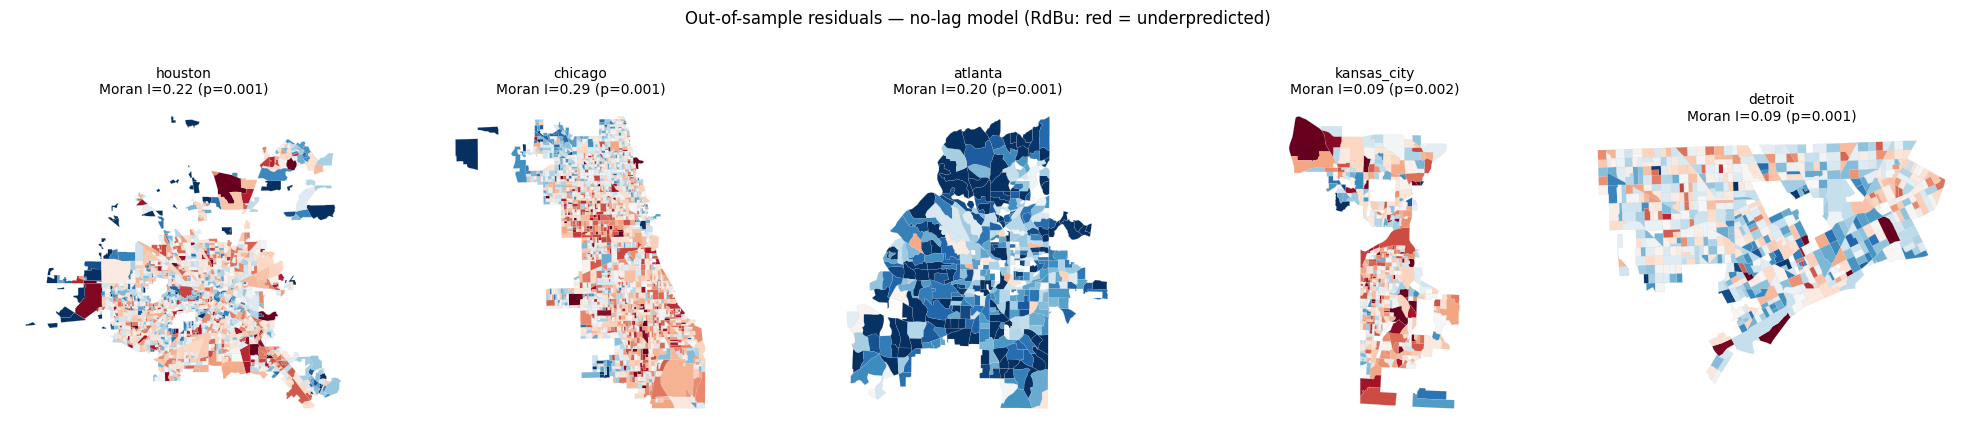

In [10]:
# choropleth of out-of-sample residuals per held-out city (no-lag model). Red = underpredicted
# (actual > predicted), blue = overpredicted. Spatially coherent colour blocks = clustering.
from regression_modelling.models.model import residual_spatial

fig, axes = plt.subplots(1, len(cities), figsize=(4 * len(cities), 4.2))
moran_rows = []
for ax, city in zip(np.atleast_1d(axes), cities):
    g = scored_nolag[scored_nolag["holdout_city"] == city]
    gdf, mi = residual_spatial(city, g["geoid"], g["resid"], k=8)
    gdf.plot(column="resid", cmap="RdBu_r", vmin=-2, vmax=2, ax=ax,
             edgecolor="0.8", linewidth=0.1)
    ax.set_title(f"{city}\nMoran I={mi.I:.2f} (p={mi.p_sim:.3f})", fontsize=10)
    ax.axis("off")
    moran_rows.append({"city": city, "n": mi.n, "moran_I_no_lag": round(mi.I, 3),
                       "p_no_lag": mi.p_sim})
plt.suptitle("Out-of-sample residuals — no-lag model (RdBu: red = underpredicted)", y=1.02)
plt.tight_layout(); plt.show()

In [11]:
# does the spatial lag REDUCE residual clustering? Compare Moran's I no-lag vs +lag per city.
rows = []
for city in cities:
    gn = scored_nolag[scored_nolag["holdout_city"] == city]
    gl = scored_lag[scored_lag["holdout_city"] == city]
    _, mn = residual_spatial(city, gn["geoid"], gn["resid"], k=8)
    _, ml = residual_spatial(city, gl["geoid"], gl["resid"], k=8)
    rows.append({"city": city, "moran_no_lag": round(mn.I, 3), "moran_lag": round(ml.I, 3),
                 "Δ moran": round(ml.I - mn.I, 3),
                 "p_no_lag": round(mn.p_sim, 3), "p_lag": round(ml.p_sim, 3)})
pd.DataFrame(rows).set_index("city")

Houston state block groups loaded: 18,626


Houston city boundary loaded: 1 row(s)


/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid


Block groups within city: 1,629 / 18,626


Houston state block groups loaded: 18,626


...

/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid


Detroit state block groups loaded: 8,340


Detroit city boundary loaded: 1 row(s)
Block groups within city: 622 / 8,340


/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/crime_blockgroup_mapping/boundaries.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid


,moran_no_lag,moran_lag,Δ moran,p_no_lag,p_lag
city,,,,,
houston,0.215,0.235,0.019,0.001,0.001
chicago,0.287,0.218,-0.069,0.001,0.001
atlanta,0.202,0.268,0.066,0.001,0.001
kansas_city,0.087,0.083,-0.005,0.001,0.001
detroit,0.094,0.112,0.018,0.001,0.001


## 4 — Model-form probe: LightGBM (same target, folds, features)

Only the estimator changes (OLS → gradient-boosted trees). If GBM materially beats OLS the
predictors carry nonlinear signal the linear form can't reach; if they tie, the linear form is
fine and **better features** are the lever. `n_jobs=1` — `-1` oversubscribes threads on this VM.

In [12]:
import lightgbm as lgb

LGB_PARAMS = dict(
    n_estimators=400, learning_rate=0.03, num_leaves=31,
    subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
    min_child_samples=30, reg_lambda=1.0, random_state=0,
    n_jobs=1, verbosity=-1,
)

def run_loco_gbm(pooled, mode="lograte", category=CATEGORY,
                 predictors=PREDICTOR_COLS, params=None):
    """LOCO with LightGBM — same folds/features/target as OLS, so any gap is model FORM.
    Returns a run dict consumable by loco_metrics / plot_lorenz."""
    params = params or LGB_PARAMS
    fits, parts = {}, []
    print(f"LOCO-GBM — mode={mode!r} ({category})")
    for city, train, holdout in loco_folds(pooled):
        tr = train.copy()
        tr["_y"] = make_target(tr, mode, category)
        tr = tr.dropna(subset=list(predictors) + ["_y"])
        ho = holdout.dropna(subset=list(predictors)).copy()
        model = lgb.LGBMRegressor(**params).fit(tr[predictors], tr["_y"])
        ho["y_pred"] = model.predict(ho[predictors])
        fits[city] = model
        parts.append(ho.assign(holdout_city=city))
        print(f"  holdout={city:14} n_train={len(tr):>5} scored={len(ho):>5}")
    return {"scored": pd.concat(parts, ignore_index=True), "fits": fits,
            "mode": mode, "category": category, "predictors": list(predictors)}

gbm = run_loco_gbm(pooled, mode="lograte")

LOCO-GBM — mode='lograte' (wtotal)


  holdout=atlanta        n_train= 4645 scored=  369


  holdout=chicago        n_train= 2950 scored= 2064


  holdout=detroit        n_train= 4414 scored=  600


  holdout=houston        n_train= 3478 scored= 1536


  holdout=kansas_city    n_train= 4569 scored=  445


In [13]:
# OLS vs LightGBM on the SAME absolute log-rate target / folds — MAE + adjusted-R2 view
def pooled_row(run, label):
    r = loco_metrics(run).loc["POOLED"]
    return {"model": label, "mae": r["mae"], "r2_oos": r["r2_oos"],
            "skill": r["skill"], "spearman": r["spearman"]}

pd.DataFrame([pooled_row(run_pool, "OLS (linear)"),
              pooled_row(gbm,       "LightGBM")]).set_index("model")

,mae,r2_oos,skill,spearman
model,,,,
OLS (linear),0.73,0.227,0.580,0.627
LightGBM,0.69,0.368,0.576,0.622


### 4.1 — SHAP feature importance

Mean absolute SHAP value per predictor, averaged over the LOCO folds (each fold's holdout
scored by that fold's model). SHAP attributes each prediction to its features in the target's
log-rate units, so the bars are directly comparable across predictors.

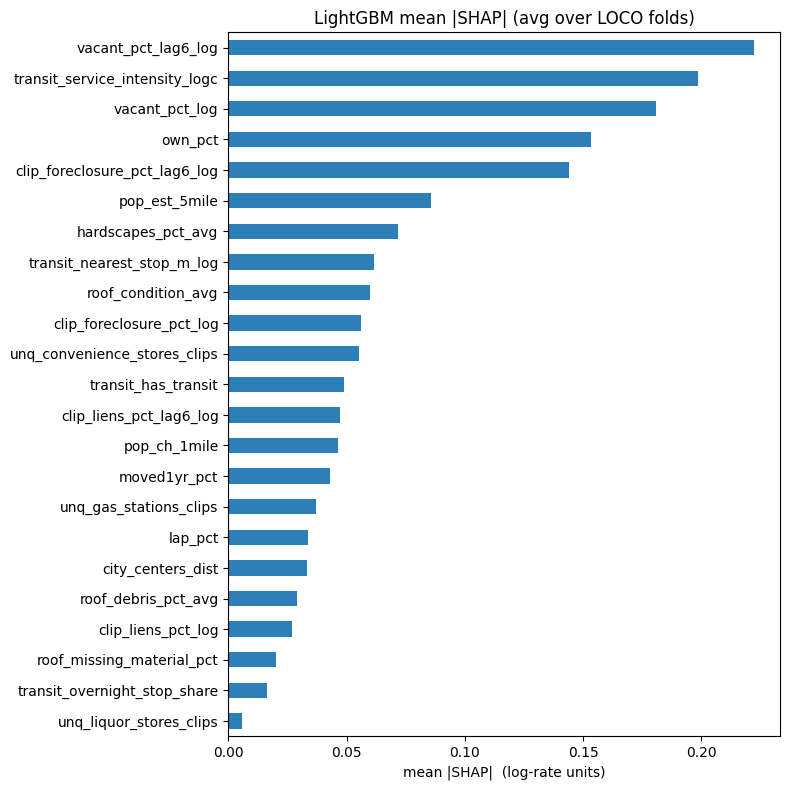

In [14]:
import shap

shap_tot = pd.Series(0.0, index=PREDICTOR_COLS)
scored = gbm["scored"]
for city, model in gbm["fits"].items():
    X = scored.loc[scored["holdout_city"] == city, PREDICTOR_COLS]
    sv = shap.TreeExplainer(model).shap_values(X)
    shap_tot += np.abs(sv).mean(axis=0)
shap_imp = (shap_tot / len(gbm["fits"])).sort_values()

ax = shap_imp.plot.barh(figsize=(8, 8), color="#2c7fb8")
ax.set_title("LightGBM mean |SHAP| (avg over LOCO folds)")
ax.set_xlabel("mean |SHAP|  (log-rate units)")
plt.tight_layout(); plt.show()

SHAP beeswarm — holdout = chicago


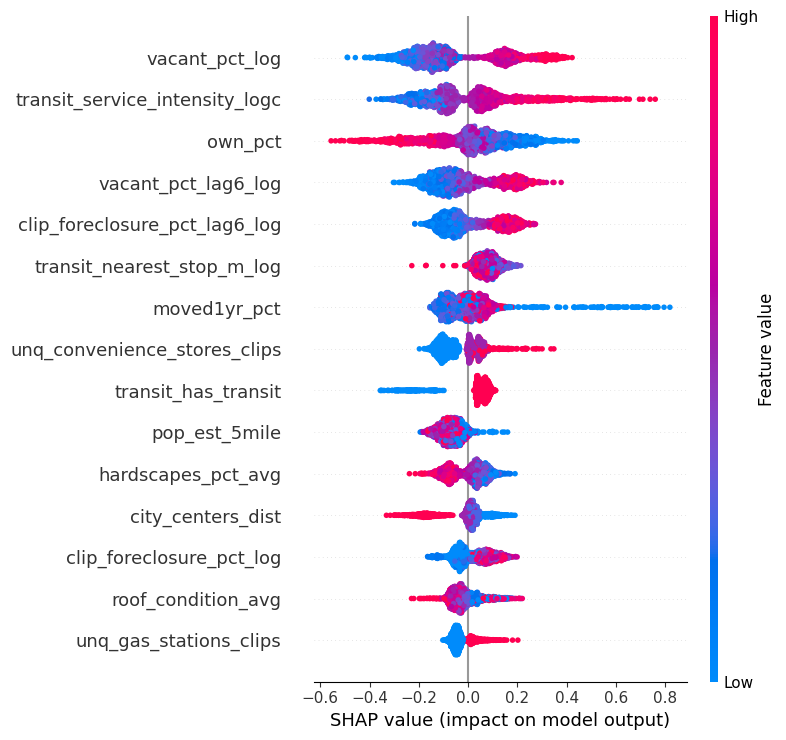

In [15]:
# beeswarm for one representative fold (largest holdout) — direction + magnitude of effects
big = max(gbm["fits"], key=lambda c: (scored["holdout_city"] == c).sum())
Xb = scored.loc[scored["holdout_city"] == big, PREDICTOR_COLS]
sv = shap.TreeExplainer(gbm["fits"][big]).shap_values(Xb)
print(f"SHAP beeswarm — holdout = {big}")
shap.summary_plot(sv, Xb, show=True, max_display=15)

## 5 — Takeaways

- **Target.** One product-aligned target throughout: `log(weighted total rate)`, population
  denominator, evaluated with adjusted R² (fit) + MAE (OOS) under LOCO.
- **Spatial lag.** The KNN(6) neighbour-context terms lift in-sample adjusted R² in every city
  and within-city ranking (Spearman) in most — the transferable spatial signal we wanted, and
  they reduce residual Moran's I where autocorrelation was strongest.
- **Residual geography.** Out-of-sample residuals still cluster spatially (positive Moran's I),
  and absolute-level transfer to a held-out city remains the hard part — the standing argument
  for an explicit spatial control (spatial-lag / error model or light city effects) beyond the
  current predictors.
- **Model form.** LightGBM vs OLS shows whether the ceiling is linearity or the feature set;
  SHAP ranks which predictors carry the weight for the leadership story.